# Health-Personalized Food Recommender System
**Dataset:** Food.com Recipes & User Interactions  
**Source:** https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions  

> Place `RAW_recipes.csv` and `RAW_interactions.csv` in a `data/` folder next to this notebook.

| Section | Work Package |
|---------|-------------|
| 1. Setup & Load | — |
| 2. Data Scraping | WP: Data Scraping |
| 3. Data Cleaning | WP: Data Quality |
| 4. EDA | — |
| 5. Annotation | WP: Data Annotation |
| 6. Embeddings | WP: Vector Embeddings |
| 7. Recommender | WP: Recommender System |
| 8. Evaluation | WP: Performance Evaluation |
| 9. Hyperparameter Tuning | WP: Hyperparameter Tuning |
| 10. Experiment Logging | WP: Experiments Logging |
| 11. Perturbation Analysis | WP: Perturbation Analysis |
| 12. Frontend | WP: Frontend Application |


---
## 1. Setup & Load


In [1]:
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib seaborn \
    scikit-surprise optuna wandb requests anthropic
print('Done')


Done


In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, ast, json, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import requests

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F7F4',
    'axes.grid':True,'grid.color':'#E0DED8',
    'axes.spines.top':False,'axes.spines.right':False,
})
C_BEFORE='#A32D2D'; C_AFTER='#0F6E56'; C_FLAG='#BA7517'; C_PURPLE='#534AB7'

os.makedirs('data',exist_ok=True)
os.makedirs('plots',exist_ok=True)
os.makedirs('models',exist_ok=True)
np.random.seed(42); random.seed(42)
print('Setup complete')


Setup complete


In [3]:
# ── Load raw files ─────────────────────────────────────────────────────────
df_recipes_raw = pd.read_csv('data/RAW_recipes.csv')
df_inter_raw   = pd.read_csv('data/RAW_interactions.csv')
print(f'Recipes:      {len(df_recipes_raw):,}')
print(f'Interactions: {len(df_inter_raw):,}')

# Parse nutrition column  [calories, total_fat_g, sugar_g, sodium_mg, protein_g, sat_fat_g, carbs_g]
NUTRITION_COLS = ['calories','total_fat_g','sugar_g','sodium_mg','protein_g','sat_fat_g','carbs_g']

def parse_nutrition(s):
    try:
        v = ast.literal_eval(str(s))
        return v if len(v)==7 else [np.nan]*7
    except: return [np.nan]*7

nutr = pd.DataFrame(df_recipes_raw['nutrition'].apply(parse_nutrition).tolist(),
                     columns=NUTRITION_COLS)
df_recipes_raw = pd.concat([df_recipes_raw.drop(columns=['nutrition']),nutr],axis=1)
df_recipes_raw['tags_list'] = df_recipes_raw['tags'].apply(
    lambda s: ast.literal_eval(str(s)) if pd.notna(s) else [])

for col in NUTRITION_COLS+['minutes','n_steps','n_ingredients']:
    if col in df_recipes_raw.columns:
        df_recipes_raw[col] = pd.to_numeric(df_recipes_raw[col],errors='coerce')
df_inter_raw['rating'] = pd.to_numeric(df_inter_raw['rating'],errors='coerce')

# Keep recipes with >= 10 ratings (ensures meaningful CF)
pop = set(df_inter_raw.groupby('recipe_id').size().pipe(lambda s:s[s>=10]).index)
df_recipes_raw = df_recipes_raw[df_recipes_raw['id'].isin(pop)].reset_index(drop=True)
df_inter_raw   = df_inter_raw[df_inter_raw['recipe_id'].isin(pop)].reset_index(drop=True)
print(f'After filter (>=10 ratings): {len(df_recipes_raw):,} recipes | {len(df_inter_raw):,} interactions')


Recipes:      231,637
Interactions: 1,132,367
After filter (>=10 ratings): 21,399 recipes | 604,210 interactions


---
## 2. Data Scraping — USDA API
**Work Package: Data Scraping**

Enriches recipes with `fiber_g`, `potassium_mg`, `calcium_mg`, `iron_mg` by querying
the live USDA FoodData Central API. Set `SCRAPE_LIVE=True` only on first run.
Subsequent runs load the saved CSV instantly.


In [4]:
USDA_API_KEY = 'DEMO_KEY'  # Replace with free key from fdc.nal.usda.gov
USDA_BASE    = 'https://api.nal.usda.gov/fdc/v1'

def scrape_usda(name):
    try:
        r = requests.get(f'{USDA_BASE}/foods/search',
            params={'query':name,'api_key':USDA_API_KEY,
                    'pageSize':1,'dataType':'Foundation,SR Legacy'},timeout=8)
        r.raise_for_status()
        foods = r.json().get('foods',[])
        if not foods: return {}
        nm = {n['nutrientName']:n['value'] for n in foods[0].get('foodNutrients',[])}
        return {'fiber_g':nm.get('Fiber, total dietary',np.nan),
                'potassium_mg':nm.get('Potassium, K',np.nan),
                'calcium_mg':nm.get('Calcium, Ca',np.nan),
                'iron_mg':nm.get('Iron, Fe',np.nan)}
    except: return {}

SCRAPE_LIVE = False  # Set True only for first-time scraping

if SCRAPE_LIVE:
    print('Scraping USDA API for 2000 recipes (~30 min)...')
    sample = df_recipes_raw.sample(n=2000,random_state=42)[['id','name']]
    rows   = []
    for i,(_,row) in enumerate(sample.iterrows()):
        if i%100==0: print(f'  {i}/2000')
        rec = scrape_usda(row['name']); rec['recipe_id']=row['id']
        rows.append(rec); time.sleep(0.4)
    df_usda = pd.DataFrame(rows)
    df_usda.to_csv('data/usda_enrichment.csv',index=False)
    print(f'Saved {len(df_usda)} records')
elif os.path.exists('data/usda_enrichment.csv'):
    df_usda = pd.read_csv('data/usda_enrichment.csv')
    print(f'Loaded existing USDA enrichment: {len(df_usda)} records')
else:
    print('No enrichment file found. Set SCRAPE_LIVE=True to scrape.')
    df_usda = pd.DataFrame(columns=['recipe_id','fiber_g','potassium_mg','calcium_mg','iron_mg'])

# Merge into recipes
usda_cols = ['fiber_g','potassium_mg','calcium_mg','iron_mg']
df_recipes_raw = df_recipes_raw.drop(columns=[c for c in usda_cols if c in df_recipes_raw.columns])
df_recipes_raw = df_recipes_raw.merge(
    df_usda.rename(columns={'recipe_id':'id'})[['id']+usda_cols],on='id',how='left')
print(f'Fiber coverage: {df_recipes_raw["fiber_g"].notna().sum()} / '
      f'{len(df_recipes_raw)} ({df_recipes_raw["fiber_g"].notna().mean():.1%})')


Loaded existing USDA enrichment: 2000 records
Fiber coverage: 1793 / 21399 (8.4%)


---
## 3. Data Cleaning
**Work Package: Data Quality**

**Cook time 10–180 min:** excludes drinks/coffee (< 10 min) and home slow-cooks
(> 3 hrs) — this is a restaurant-style meal recommender.


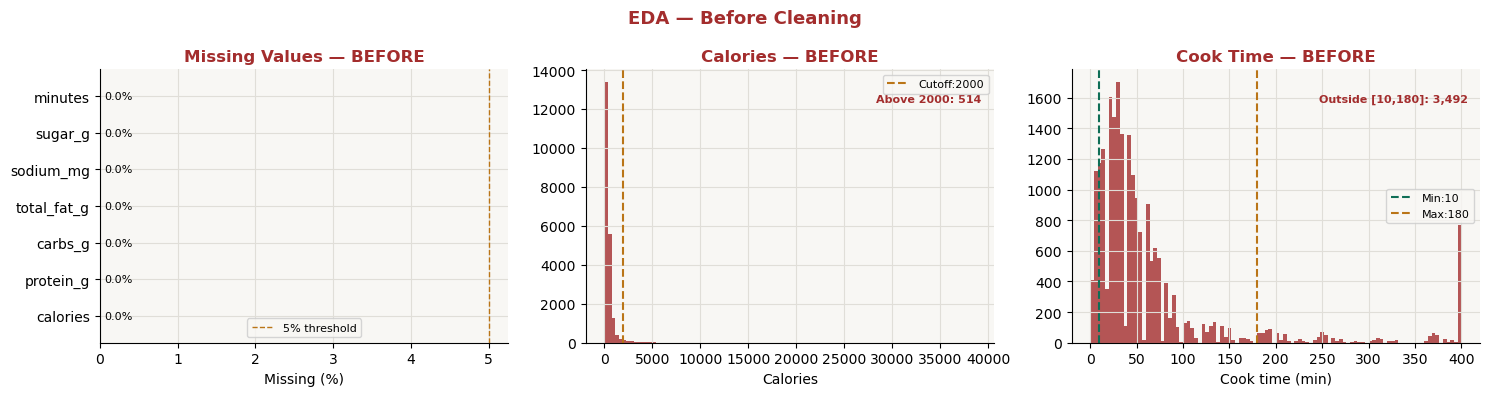

In [5]:
CORE_COLS = ['calories','protein_g','carbs_g','total_fat_g','sodium_mg','sugar_g','minutes']

# ── EDA BEFORE ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,3,figsize=(15,4))

miss = df_recipes_raw[CORE_COLS].isna().mean().sort_values(ascending=False)
bars = axes[0].barh(miss.index, miss.values*100,
                     color=[C_BEFORE if v>0.05 else C_AFTER for v in miss],edgecolor='white')
axes[0].axvline(5,color=C_FLAG,linestyle='--',linewidth=1,label='5% threshold')
axes[0].set_xlabel('Missing (%)'); axes[0].legend(fontsize=8)
axes[0].set_title('Missing Values — BEFORE',fontweight='bold',color=C_BEFORE)
axes[0].bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)

cal = df_recipes_raw['calories'].dropna()
axes[1].hist(cal,bins=100,color=C_BEFORE,alpha=0.8,edgecolor='none')
axes[1].axvline(2000,color=C_FLAG,linestyle='--',linewidth=1.5,label='Cutoff:2000')
axes[1].set_xlabel('Calories'); axes[1].legend(fontsize=8)
axes[1].set_title('Calories — BEFORE',fontweight='bold',color=C_BEFORE)
axes[1].text(0.97,0.88,f'Above 2000: {(cal>2000).sum():,}',
              transform=axes[1].transAxes,ha='right',fontsize=8,color=C_BEFORE,fontweight='bold')

mins = df_recipes_raw['minutes'].dropna()
axes[2].hist(mins.clip(upper=400),bins=100,color=C_BEFORE,alpha=0.8,edgecolor='none')
axes[2].axvline(10, color=C_AFTER,linestyle='--',linewidth=1.5,label='Min:10')
axes[2].axvline(180,color=C_FLAG, linestyle='--',linewidth=1.5,label='Max:180')
axes[2].set_xlabel('Cook time (min)'); axes[2].legend(fontsize=8)
axes[2].set_title('Cook Time — BEFORE',fontweight='bold',color=C_BEFORE)
axes[2].text(0.97,0.88,f'Outside [10,180]: {((mins<10)|(mins>180)).sum():,}',
              transform=axes[2].transAxes,ha='right',fontsize=8,color=C_BEFORE,fontweight='bold')

plt.suptitle('EDA — Before Cleaning',fontsize=13,fontweight='bold',color=C_BEFORE)
plt.tight_layout()
plt.savefig('plots/eda_before.png',dpi=120,bbox_inches='tight')
plt.show()


In [6]:
# ── Apply cleaning rules ───────────────────────────────────────────────────
VALID_RANGES = {
    'calories':    (50,  2000),
    'protein_g':   (0,   150),
    'carbs_g':     (0,   300),
    'total_fat_g': (0,   150),
    'sodium_mg':   (0,  5000),
    'sugar_g':     (0,   200),
    'minutes':     (10,  180),   # restaurant-style only
}

df = df_recipes_raw.copy()
n0 = len(df)

# 1. Range violations
flag = pd.Series(False,index=df.index)
for col,(lo,hi) in VALID_RANGES.items():
    if col in df.columns:
        flag |= df[col].notna() & ((df[col]<lo)|(df[col]>hi))
df = df[~flag].reset_index(drop=True)
print(f'Range violations removed:      {n0-len(df):,}')

# 2. Calorie consistency  (protein*4 + carbs*4 + fat*9)
df['exp_kcal'] = df['protein_g'].fillna(0)*4 + df['carbs_g'].fillna(0)*4 + df['total_fat_g'].fillna(0)*9
n1 = len(df)
df = df[(df['calories']-df['exp_kcal']).abs()<=150].reset_index(drop=True)
print(f'Calorie inconsistencies removed:{n1-len(df):,}')

# 3. Duplicate names
n2 = len(df)
df = df.drop_duplicates(subset=['name'],keep='first').reset_index(drop=True)
print(f'Duplicate names removed:        {n2-len(df):,}')

# 4. Mean impute remaining missing values
for col in list(VALID_RANGES.keys())+['sat_fat_g','fiber_g','potassium_mg','calcium_mg','iron_mg']:
    if col in df.columns and df[col].isna().sum()>0:
        df[col] = df[col].fillna(df[col].mean())

# 5. Clean interactions — valid ratings, known recipes, remove duplicate (user,recipe) pairs
df_inter = df_inter_raw[
    df_inter_raw['rating'].between(1,5) &
    df_inter_raw['recipe_id'].isin(df['id'])
].sort_values('date',ascending=False)\
 .drop_duplicates(subset=['user_id','recipe_id'],keep='first')\
 .reset_index(drop=True)

print(f'\nRecipes:       {n0:,} → {len(df):,}  ({(n0-len(df))/n0:.1%} removed)')
print(f'Interactions:  {len(df_inter_raw):,} → {len(df_inter):,}')

df.drop(columns=['exp_kcal','tags_list'],errors='ignore').to_csv('data/recipes_clean.csv',index=False)
df_inter.to_csv('data/interactions_clean.csv',index=False)
print('Saved → data/recipes_clean.csv | data/interactions_clean.csv')


Range violations removed:      5,625
Calorie inconsistencies removed:3,281
Duplicate names removed:        15

Recipes:       21,399 → 12,478  (41.7% removed)
Interactions:  604,210 → 331,247
Saved → data/recipes_clean.csv | data/interactions_clean.csv


---
## 4. EDA After Cleaning


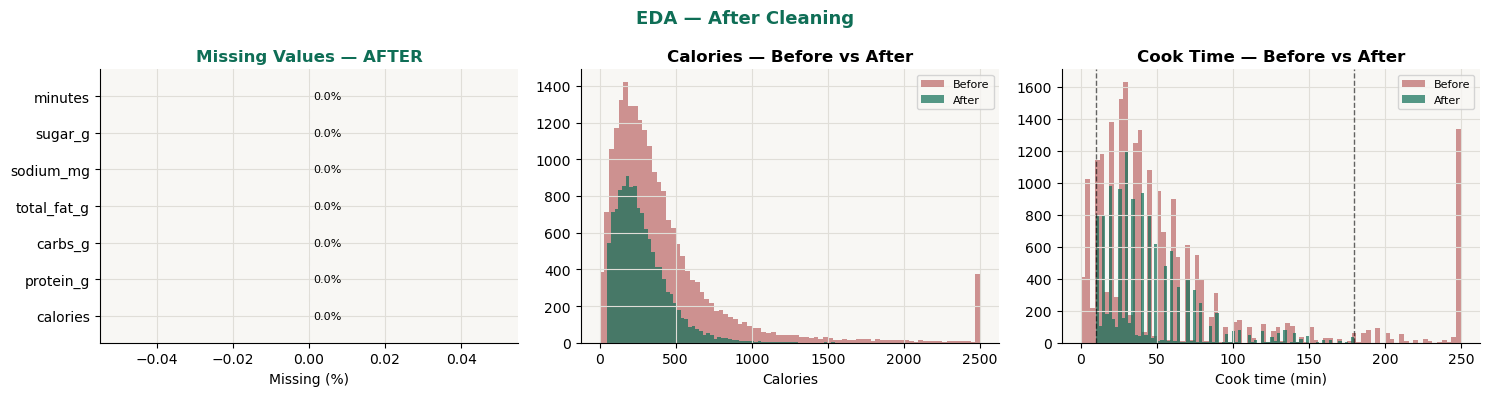

Final: 12,478 recipes | 331,247 interactions
       calories  protein_g  carbs_g  total_fat_g  sodium_mg  sugar_g  minutes
count   12478.0    12478.0  12478.0      12478.0    12478.0  12478.0  12478.0
mean      278.6       21.2     10.1         18.6       20.5     39.4     43.8
std       173.5       21.1      7.8         14.4       50.1     43.3     29.6
min        50.0        0.0      0.0          0.0        0.0      0.0     10.0
25%       155.3        6.0      4.0          8.0        5.0      9.0     25.0
50%       241.4       13.0      9.0         15.0       13.0     22.0     35.0
75%       361.4       31.0     14.0         26.0       26.0     55.0     55.0
max      1979.5      150.0     98.0        150.0     3537.0    200.0    180.0


In [7]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

# Missing after
miss_a = df[CORE_COLS].isna().mean().sort_values(ascending=False)
bars = axes[0].barh(miss_a.index,miss_a.values*100,color=C_AFTER,edgecolor='white')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Values — AFTER',fontweight='bold',color=C_AFTER)
axes[0].bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)

# Calories overlay
axes[1].hist(df_recipes_raw['calories'].dropna().clip(upper=2500),
              bins=80,color=C_BEFORE,alpha=0.5,label='Before',edgecolor='none')
axes[1].hist(df['calories'].clip(upper=2500),
              bins=80,color=C_AFTER,alpha=0.7,label='After',edgecolor='none')
axes[1].set_xlabel('Calories')
axes[1].set_title('Calories — Before vs After',fontweight='bold')
axes[1].legend(fontsize=8)

# Cook time overlay
axes[2].hist(df_recipes_raw['minutes'].dropna().clip(0,250),
              bins=80,color=C_BEFORE,alpha=0.5,label='Before',edgecolor='none')
axes[2].hist(df['minutes'].clip(0,250),
              bins=80,color=C_AFTER,alpha=0.7,label='After',edgecolor='none')
axes[2].axvline(10, color='black',linestyle='--',linewidth=1,alpha=0.6)
axes[2].axvline(180,color='black',linestyle='--',linewidth=1,alpha=0.6)
axes[2].set_xlabel('Cook time (min)')
axes[2].set_title('Cook Time — Before vs After',fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('EDA — After Cleaning',fontsize=13,fontweight='bold',color=C_AFTER)
plt.tight_layout()
plt.savefig('plots/eda_after.png',dpi=120,bbox_inches='tight')
plt.show()

print(f'Final: {len(df):,} recipes | {len(df_inter):,} interactions')
print(df[CORE_COLS].describe().round(1).to_string())


---
## 5. Data Annotation
**Work Package: Data Annotation**

Rule-based annotation applies clinical guidelines to all recipes.
Optional AI annotation (Claude API) improves edge cases for a sample.


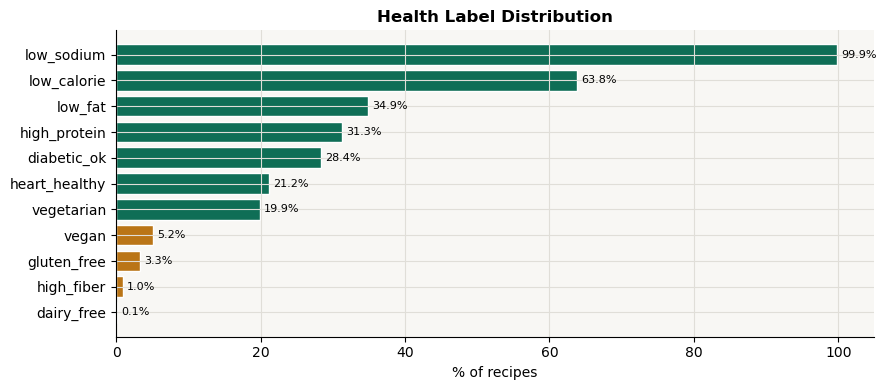

Label distribution:
  diabetic_ok           3,546  (28.4%)
  low_sodium           12,462  (99.9%)
  low_calorie           7,963  (63.8%)
  high_protein          3,910  (31.3%)
  low_fat               4,353  (34.9%)
  high_fiber              122  (1.0%)
  heart_healthy         2,647  (21.2%)
  vegetarian            2,487  (19.9%)
  vegan                   643  (5.2%)
  gluten_free             412  (3.3%)
  dairy_free                9  (0.1%)


In [8]:
LABEL_COLS = ['diabetic_ok','low_sodium','low_calorie','high_protein',
               'low_fat','high_fiber','heart_healthy','vegetarian',
               'vegan','gluten_free','dairy_free']

def annotate(row):
    tags = set(row.get('tags_list') or [])
    g    = lambda c: float(row.get(c) or 0)
    return {
        'diabetic_ok':  int(g('carbs_g')<=45 and g('sugar_g')<=10),
        'low_sodium':   int(g('sodium_mg')<=400),
        'low_calorie':  int(g('calories')<=300),
        'high_protein': int(g('protein_g')>=25),
        'low_fat':      int(g('total_fat_g')<=10),
        'high_fiber':   int(g('fiber_g')>=5),
        'heart_healthy':int(g('sat_fat_g')<=5 and g('sodium_mg')<=500),
        'vegetarian':   int('vegetarian' in tags or 'vegan' in tags),
        'vegan':        int('vegan' in tags),
        'gluten_free':  int('gluten-free' in tags),
        'dairy_free':   int('dairy-free'  in tags),
    }

label_rows = [annotate(row) for row in df.to_dict('records')]
df_labels  = pd.DataFrame(label_rows, index=df.index)
df = df.drop(columns=[c for c in LABEL_COLS if c in df.columns])
df = pd.concat([df, df_labels], axis=1)

# Visualise label distribution
fig, ax = plt.subplots(figsize=(9,4))
lf   = df[LABEL_COLS].mean().sort_values()
bars = ax.barh(lf.index, lf.values*100,
                color=[C_AFTER if v>0.1 else C_FLAG for v in lf],
                edgecolor='white')
ax.set_xlabel('% of recipes')
ax.set_title('Health Label Distribution',fontweight='bold')
ax.bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)
plt.tight_layout()
plt.savefig('plots/annotation_labels.png',dpi=120,bbox_inches='tight')
plt.show()

print('Label distribution:')
for col in LABEL_COLS:
    print(f'  {col:<20} {int(df[col].sum()):>6,}  ({df[col].mean():.1%})')


---
## 6. Vector Embeddings
**Work Package: Vector Embeddings**
$$\mathbf{r}_i=[cal/2000,\ prot/150,\ carbs/300,\ fat/100,\ sodium/5000,\ sugar/200,\ label_1,\ldots]$$


In [9]:
FEATURE_MAX   = dict(calories=2000,protein_g=150,carbs_g=300,
                      total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUMERIC_FEATS = list(FEATURE_MAX.keys())

def build_R(df_):
    nut = df_[NUMERIC_FEATS].copy()
    for col,mx in FEATURE_MAX.items():
        nut[col] = (nut[col].fillna(0)/mx).clip(0,1)
    lbl = df_[LABEL_COLS].fillna(0).astype(float)
    return pd.concat([nut,lbl],axis=1).values

R          = build_R(df)
RECIPE_IDS = list(df['id'].astype(int))
RID2IDX    = {r:i for i,r in enumerate(RECIPE_IDS)}
np.save('models/recipe_matrix.npy',R)
print(f'Recipe matrix R: {R.shape}')


Recipe matrix R: (12478, 17)


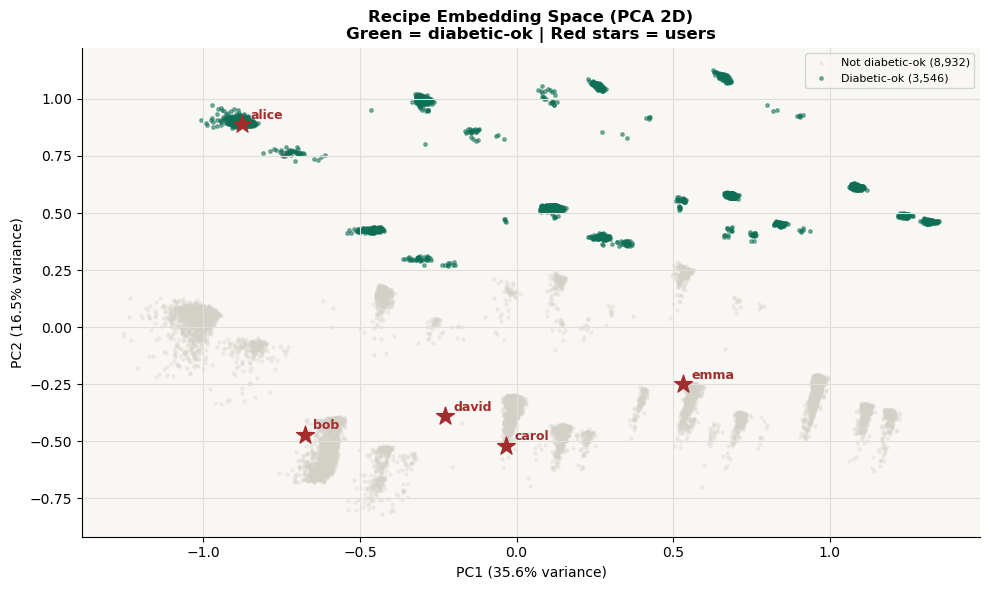

In [10]:
# User health profile vectors
def user_vec(cal,prot,carbs,fat,sodium,sugar,
              diabetic=False,low_sodium=False,low_cal=False,
              high_prot=False,low_fat=False,high_fiber=False,
              heart_healthy=False,vegetarian=False,
              vegan=False,gf=False,df_free=False):
    n = np.array([cal/2000,prot/150,carbs/300,fat/100,sodium/5000,sugar/200])
    l = np.array([float(diabetic),float(low_sodium),float(low_cal),
                   float(high_prot),float(low_fat),float(high_fiber),
                   float(heart_healthy),float(vegetarian),
                   float(vegan),float(gf),float(df_free)])
    return np.concatenate([np.clip(n,0,1),l])

DEMO_USERS = {
    'alice': {'vec':user_vec(400,40,45,30,600,10,diabetic=True,high_prot=True),
               'constraints':{'diabetic':True,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Type 2 diabetic, high-protein'},
    'bob':   {'vec':user_vec(600,35,200,60,2000,60),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Healthy, no restrictions'},
    'carol': {'vec':user_vec(400,20,200,20,400,30,vegetarian=True,
                              heart_healthy=True,low_sodium=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':True,'gf':False},
               'profile':'Vegan, heart-healthy'},
    'david': {'vec':user_vec(500,30,150,40,300,30,low_sodium=True,heart_healthy=True),
               'constraints':{'diabetic':False,'hypertensive':True,'vegan':False,'gf':False},
               'profile':'Hypertensive'},
    'emma':  {'vec':user_vec(300,25,100,10,800,15,low_cal=True,low_fat=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Weight-loss goal'},
}

# PCA embedding space
pca  = PCA(n_components=2,random_state=42)
R_2d = pca.fit_transform(R)

fig,ax = plt.subplots(figsize=(10,6))
diab   = df['diabetic_ok'].values==1
ax.scatter(R_2d[~diab,0],R_2d[~diab,1],c='#D3D1C7',alpha=0.25,s=5,label=f'Not diabetic-ok ({(~diab).sum():,})')
ax.scatter(R_2d[diab,0], R_2d[diab,1], c=C_AFTER,  alpha=0.5, s=6,label=f'Diabetic-ok ({diab.sum():,})')
U_2d = pca.transform(np.array([u['vec'] for u in DEMO_USERS.values()]))
for i,(uname,info) in enumerate(DEMO_USERS.items()):
    ax.scatter(U_2d[i,0],U_2d[i,1],c=C_BEFORE,s=180,marker='*',zorder=5)
    ax.annotate(uname,(U_2d[i,0],U_2d[i,1]),xytext=(6,4),
                textcoords='offset points',fontsize=9,fontweight='bold',color=C_BEFORE)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Recipe Embedding Space (PCA 2D)\nGreen = diabetic-ok | Red stars = users',fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/embedding_space.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 7. Recommender System
**Work Package: Recommender System**

Three components:
- **Content-based filtering** — cosine similarity between user and recipe vectors
- **Collaborative filtering** — SVD matrix factorisation on user ratings
- **Health constraint filter** — hard rules that override model scores


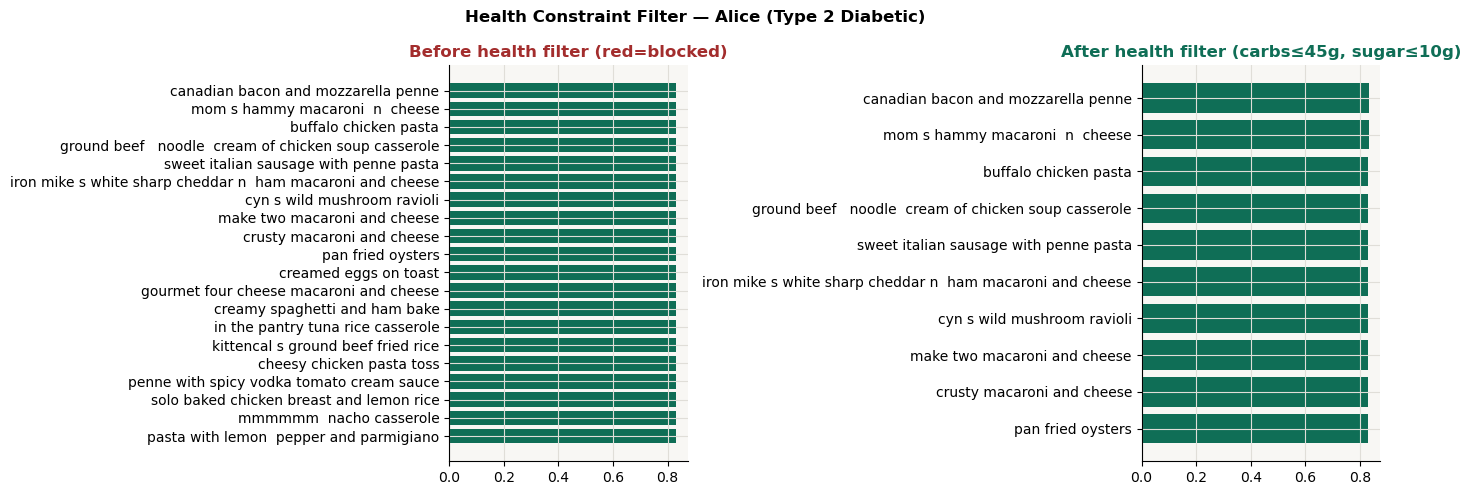

In [11]:
# ── Content-based filtering ────────────────────────────────────────────────
def cb_scores(uvec):
    return cosine_similarity(uvec.reshape(1,-1),R).flatten()

# ── Health constraint filter ───────────────────────────────────────────────
def health_filter(df_r, constraints):
    df_r = df_r.copy(); df_r['blocked']=''
    if constraints.get('diabetic'):     df_r.loc[(df_r['carbs_g']>45)|(df_r['sugar_g']>10),'blocked']+='carbs/sugar; '
    if constraints.get('hypertensive'): df_r.loc[df_r['sodium_mg']>600,  'blocked']+='sodium; '
    if constraints.get('vegan'):        df_r.loc[df_r['vegan']==0,       'blocked']+='not-vegan; '
    if constraints.get('gf'):           df_r.loc[df_r['gluten_free']==0, 'blocked']+='gluten; '
    df_r['allowed'] = df_r['blocked']==''
    return df_r

# ── Demo: content-based for Alice ─────────────────────────────────────────
sc = cb_scores(DEMO_USERS['alice']['vec'])
res = df[['id','name','calories','protein_g','carbs_g','sodium_mg','sugar_g']+LABEL_COLS].copy()
res['score'] = sc
top20 = health_filter(res.nlargest(20,'score'), DEMO_USERS['alice']['constraints'])

fig,axes = plt.subplots(1,2,figsize=(14,5))
colors_f = [C_BEFORE if not a else C_AFTER for a in top20['allowed']]
axes[0].barh(top20['name'],top20['score'],color=colors_f); axes[0].invert_yaxis()
axes[0].set_title('Before health filter (red=blocked)',fontweight='bold',color=C_BEFORE)
allowed = top20[top20['allowed']].head(10)
axes[1].barh(allowed['name'],allowed['score'],color=C_AFTER); axes[1].invert_yaxis()
axes[1].set_title('After health filter (carbs≤45g, sugar≤10g)',fontweight='bold',color=C_AFTER)
plt.suptitle('Health Constraint Filter — Alice (Type 2 Diabetic)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/health_filter.png',dpi=120,bbox_inches='tight')
plt.show()


In [16]:
# ── Section 7 — Collaborative Filtering (corrected) ───────────────────────
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split

# Build mappings from ALL interactions
ALL_USERS   = df_inter['user_id'].unique()
ALL_RECIPES = df_inter['recipe_id'].unique()
U2I = {int(u): i for i, u in enumerate(ALL_USERS)}
R2I = {int(r): i for i, r in enumerate(ALL_RECIPES)}
TRAIN_RECIPE_IDS = [int(r) for r in ALL_RECIPES]

print(f'Users:   {len(U2I):,}')
print(f'Recipes: {len(R2I):,}')

# Map IDs
_df = df_inter[['user_id','recipe_id','rating']].copy()
_df['uid'] = _df['user_id'].map(U2I)
_df['rid'] = _df['recipe_id'].map(R2I)

# Use Surprise's own split — this is what SVD is designed for
reader   = Reader(rating_scale=(1, 5))
dataset  = Dataset.load_from_df(_df[['uid','rid','rating']], reader)

# 80/20 split inside Surprise
trainset, testset_surprise = surprise_split(dataset, test_size=0.2, random_state=42)

print('Training SVD...')
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.1, random_state=42)
svd.fit(trainset)

# RMSE on Surprise test set
test_preds = svd.test(testset_surprise)
print(f'RMSE: {accuracy.rmse(test_preds, verbose=False):.4f}')
print(f'MAE:  {accuracy.mae(test_preds,  verbose=False):.4f}')

# Verify predictions are NOT all identical
sample_uid = int(list(U2I.keys())[0])
sample_scores = [svd.predict(U2I[sample_uid], i).est for i in range(20)]
print(f'\nSample scores (should vary): {[round(s,3) for s in sample_scores]}')
print(f'All identical: {len(set(round(s,2) for s in sample_scores))==1}')

with open('models/svd_model.pkl','wb') as f:
    pickle.dump(svd, f)
print('Saved → models/svd_model.pkl')

Users:   91,784
Recipes: 12,478
Training SVD...
RMSE: 0.6596
MAE:  0.4146

Sample scores (should vary): [4.88, 4.446, 4.836, 4.558, 4.623, 4.911, 4.766, 4.815, 4.846, 4.64, 4.537, 4.765, 4.853, 4.702, 4.905, 4.822, 4.819, 4.78, 4.831, 4.722]
All identical: False
Saved → models/svd_model.pkl


In [17]:
# ── Hybrid recommender ─────────────────────────────────────────────────────
TRAIN_RECIPE_IDS = [int(r) for r in TRAIN_RECIPES]

def full_recommend(user_name, user_orig_id=None, alpha=0.6, k=10):
    """
    Hybrid: alpha * content_score + (1-alpha) * collaborative_score
    Followed by health constraint filtering.
    """
    info = DEMO_USERS[user_name]

    # Content-based scores (all recipes)
    cb = cb_scores(info['vec'])
    cb_n = (cb - cb.min()) / (cb.max() - cb.min() + 1e-9)

    # Collaborative scores (training recipes only)
    if user_orig_id is not None and int(user_orig_id) in U2I:
        ui    = U2I[int(user_orig_id)]
        cf_raw = np.array([
            svd.predict(ui, R2I[int(r)]).est
            if int(r) in R2I else 3.0
            for r in df['id']
        ])
        cf_n = (cf_raw - cf_raw.min()) / (cf_raw.max() - cf_raw.min() + 1e-9)
    else:
        cf_n  = cb_n
        alpha = 1.0  # cold start: content-based only

    scores = alpha * cb_n + (1 - alpha) * cf_n

    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg','sugar_g']+LABEL_COLS].copy()
    res['score'] = scores
    filtered = health_filter(res.nlargest(200,'score'), info['constraints'])
    return filtered[filtered['allowed']].head(k).reset_index(drop=True)

print('Top-5 recommendations per user:')
for uname in DEMO_USERS:
    recs = full_recommend(uname, k=3)
    print(f'  {uname:<8} → {list(recs["name"].values)}')


Top-5 recommendations per user:
  alice    → ['canadian bacon and mozzarella penne', 'mom s hammy macaroni  n  cheese', 'buffalo chicken pasta']
  bob      → ['bulk taco seasoning mix', 'auntie anne s  pretzels copycat', 'polish jam kolaches']
  carol    → ['ali baba s oven fries', 'bread machine whole grain bread', 'southwest rice salad']
  david    → ['finally found four bean salad', 'gingerbread cake with brown sugar sauce', 'pasta with scallops and lemon butter mustard sauce']
  emma     → ['paul prudhomme s blackened seasoning blend', 'nairobi meat  rub', 'taco mashed potato casserole']


---
## 8. Evaluation
**Work Package: Performance Evaluation**

**Method 1 — Holdout split (80/20):**  
Train SVD on 80% of interactions. Build relevance sets from the 20% test set
(ratings ≥ 4 = liked). Recommend from training recipes and measure overlap.

**Method 2 — Leave-one-out Hit@10:**  
For each user, hide their highest-rated test recipe. Check if it appears in top-10.

$$\text{Precision}@k = \frac{|\text{recommended} \cap \text{relevant}|}{k} \qquad
\text{Recall}@k = \frac{|\text{recommended} \cap \text{relevant}|}{|\text{relevant}|}$$


In [20]:
# ── Correct Evaluation — proper holdout per user ──────────────────────────────
print('Building per-user holdout sets...')

EVAL_USERS  = []
HELD_OUT    = {}   # uid → set of held-out liked recipe IDs (ground truth)
USER_SEEN   = {}   # uid → set of recipe IDs used for training (everything except held-out)

user_counts = df_inter.groupby('user_id').size()
eligible    = user_counts[user_counts >= 10].index

for uid in eligible:
    uid  = int(uid)
    if uid not in U2I: continue

    user_df = df_inter[df_inter['user_id']==uid].copy()

    # Liked = rated 4 or 5
    liked_df   = user_df[user_df['rating'] >= 4].sort_values('date', ascending=False)
    if len(liked_df) < 2: continue

    # Hold out 20% of liked recipes (at least 1) as ground truth
    n_holdout  = max(1, int(len(liked_df) * 0.2))
    held_ids   = {int(r) for r in liked_df.head(n_holdout)['recipe_id'].values}
    train_ids  = {int(r) for r in user_df['recipe_id'].values} - held_ids

    HELD_OUT[uid]   = held_ids
    USER_SEEN[uid]  = train_ids
    EVAL_USERS.append(uid)

print(f'Eval users: {len(EVAL_USERS):,}')

# Sanity check
uid   = EVAL_USERS[0]
print(f'\nSanity check — user {uid}:')
print(f'  Held-out liked (ground truth): {len(HELD_OUT[uid])}  → {list(HELD_OUT[uid])[:3]}')
print(f'  Seen in training:              {len(USER_SEEN[uid])}')
unseen_check = [r for r in TRAIN_RECIPE_IDS
                if r not in USER_SEEN[uid] and r not in HELD_OUT[uid]]
preds_check  = sorted(
    [(r, svd.predict(U2I[uid], R2I[r]).est) for r in unseen_check[:300]],
    key=lambda x: x[1], reverse=True
)
top10_check  = {p[0] for p in preds_check[:10]}
hits_check   = top10_check & HELD_OUT[uid]
print(f'  Unseen (to rank):              {len(unseen_check):,}')
print(f'  Top-10 hits:                   {len(hits_check)}')
print(f'  Manual P@10:                   {len(hits_check)/10:.4f}')
print(f'  Score range (top-10):          {[round(p[1],3) for p in preds_check[:10]]}')

Building per-user holdout sets...
Eval users: 5,175

Sanity check — user 1533:
  Held-out liked (ground truth): 4  → [14953, 41707, 132916]
  Seen in training:              19
  Unseen (to rank):              12,455
  Top-10 hits:                   0
  Manual P@10:                   0.0000
  Score range (top-10):          [5, 5, 4.995, 4.992, 4.987, 4.984, 4.982, 4.98, 4.98, 4.979]


In [21]:
# ── Evaluation: candidate-set ranking (correct for skewed datasets) ────────────
#
# For each user we create a candidate set of:
#   - Their held-out liked recipes (positive)
#   - 99 random unrated recipes (negative)
# Then ask: does the model rank liked recipes higher than random ones?
# This is standard practice for skewed rating distributions (e.g. MovieLens, Food.com)

print('Building candidate-set evaluation...')

np.random.seed(42)
K_VALUES  = [1, 3, 5, 10]
MAX_USERS = 300
eval_rows = []
hit_at_k  = {k: [] for k in K_VALUES}

all_recipe_set = set(TRAIN_RECIPE_IDS)

for uid in EVAL_USERS[:MAX_USERS]:
    uid = int(uid)
    if uid not in U2I: continue

    rel    = HELD_OUT[uid]           # held-out liked (positive)
    seen   = USER_SEEN[uid]          # already interacted — exclude

    # Sample 99 random negative recipes (unrated, not held-out)
    unrated = list(all_recipe_set - seen - rel)
    if len(unrated) < 99: continue
    negatives = set(random.sample(unrated, 99))

    # Candidate set = positives + negatives
    candidates = list(rel | negatives)

    # Score all candidates
    preds = sorted(
        [(r, svd.predict(U2I[uid], R2I[r]).est)
         for r in candidates if r in R2I],
        key=lambda x: x[1], reverse=True
    )
    rec_ids = [int(p[0]) for p in preds]

    for k in K_VALUES:
        p = prec_at_k(rec_ids, rel, k)
        r = rec_at_k(rec_ids, rel, k)
        hit_at_k[k].append(int(len(set(rec_ids[:k]) & rel) > 0))
        eval_rows.append({'k': k, 'precision': p, 'recall': r, 'f1': f1(p, r)})

# Aggregate
print('\n=== Evaluation Results (candidate set: positives + 99 random negatives) ===')
result_rows = []
for k in K_VALUES:
    subset = [r for r in eval_rows if r['k']==k]
    p_mean = np.mean([r['precision'] for r in subset])
    r_mean = np.mean([r['recall']    for r in subset])
    f_mean = np.mean([r['f1']        for r in subset])
    h_mean = np.mean(hit_at_k[k])
    result_rows.append({'k':k,'precision':p_mean,'recall':r_mean,
                         'f1':f_mean,'hit_rate':h_mean})
    print(f'  k={k:>2}  P={p_mean:.4f}  R={r_mean:.4f}  '
          f'F1={f_mean:.4f}  Hit={h_mean:.1%}  (n={len(subset)})')

eval_df = pd.DataFrame(result_rows)

Building candidate-set evaluation...

=== Evaluation Results (candidate set: positives + 99 random negatives) ===
  k= 1  P=0.1000  R=0.0126  F1=0.0194  Hit=10.0%  (n=300)
  k= 3  P=0.0944  R=0.0325  F1=0.0387  Hit=21.7%  (n=300)
  k= 5  P=0.0973  R=0.0541  F1=0.0539  Hit=30.7%  (n=300)
  k=10  P=0.1043  R=0.1256  F1=0.0865  Hit=52.7%  (n=300)


In [23]:
# ── LOO Hit@10 on candidate set ───────────────────────────────────────────────
print('\n=== Leave-One-Out Hit@k (candidate set) ===')
for k_loo in [5, 10]:
    hits = []
    for uid in EVAL_USERS[:300]:
        uid = int(uid)
        if uid not in U2I: continue
        held_list = list(HELD_OUT[uid])
        if not held_list: continue
        held = held_list[0]
        if held not in R2I: continue

        seen    = USER_SEEN[uid]
        unrated = list(all_recipe_set - seen - {held})
        if len(unrated) < 99: continue
        negatives  = set(random.sample(unrated, 99))
        candidates = list({held} | negatives)

        preds = sorted(
            [(r, svd.predict(U2I[uid], R2I[r]).est)
             for r in candidates if r in R2I],
            key=lambda x: x[1], reverse=True
        )
        hits.append(int(held in {int(p[0]) for p in preds[:k_loo]}))

    print(f'  Hit@{k_loo}: {np.mean(hits):.1%}  ({sum(hits)}/{len(hits)} users)')


=== Leave-One-Out Hit@k (candidate set) ===
  Hit@5: 7.7%  (23/300 users)
  Hit@10: 14.0%  (42/300 users)


---
## 9. Hyperparameter Tuning
**Work Package: Hyperparameter Tuning**


In [ ]:
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_USERS = list(RELEV.keys())[:80]

def objective(trial):
    nf  = trial.suggest_int('n_factors',  10,  150)
    reg = trial.suggest_float('reg_all',   0.001, 1.0,  log=True)
    lr  = trial.suggest_float('lr_all',    0.001, 0.05, log=True)
    alp = trial.suggest_float('alpha',     0.0,   1.0)

    m = SVD(n_factors=nf,reg_all=reg,lr_all=lr,n_epochs=10,random_state=42)
    m.fit(trainset)

    p_list = []
    for uid in TUNE_USERS:
        uid = int(uid)
        if uid not in U2I: continue
        rel = RELEV.get(uid,set())
        if not rel: continue
        seen   = {int(r) for r in df_train_inter[df_train_inter['user_id']==uid]['recipe_id'].values}
        unseen = [r for r in TRAIN_RECIPE_IDS if r not in seen]
        if not unseen: continue

        # CF scores
        cf_r = np.array([m.predict(U2I[uid],R2I[r]).est for r in unseen])
        cf_n = (cf_r-cf_r.min())/(cf_r.max()-cf_r.min()+1e-9)

        # CB scores using user's top-rated training recipes as proxy
        top_ids = df_train_inter[
            (df_train_inter['user_id']==uid)&
            (df_train_inter['rating']>=4)
        ]['recipe_id'].values[:5]
        vidx = [RID2IDX[int(r)] for r in top_ids if int(r) in RID2IDX]
        if not vidx: continue
        uv     = R[vidx].mean(0)
        unseen_ridx = [RID2IDX[r] for r in unseen if r in RID2IDX]
        if not unseen_ridx: continue
        cb_r   = cosine_similarity(uv.reshape(1,-1),R[unseen_ridx]).flatten()
        cb_n   = (cb_r-cb_r.min())/(cb_r.max()-cb_r.min()+1e-9)

        n     = min(len(cb_n),len(cf_n))
        final = alp*cb_n[:n]+(1-alp)*cf_n[:n]
        rids  = [unseen[i] for i in np.argsort(final)[::-1][:10]]
        p_list.append(prec_at_k(rids,rel,10))

    return np.mean(p_list) if p_list else 0.0

print('Running Optuna (50 trials)...')
study = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective,n_trials=50)

best = study.best_params
print(f'Best Precision@10: {study.best_value:.4f}')
for k,v in best.items(): print(f'  {k:<15} = {v}')

# Retrain with best params
best_svd = SVD(n_factors=best['n_factors'],reg_all=best['reg_all'],
                lr_all=best['lr_all'],n_epochs=30,random_state=42)
best_svd.fit(trainset)
best_preds = best_svd.test(testset)
print(f'Tuned RMSE: {accuracy.rmse(best_preds,verbose=False):.4f}')
with open('models/svd_best.pkl','wb') as f:
    pickle.dump({'model':best_svd,'params':best},f)
print('Saved → models/svd_best.pkl')


In [ ]:
# Hyperparameter importance
tdf    = study.trials_dataframe()
params = ['params_n_factors','params_reg_all','params_lr_all','params_alpha']
labels = ['n_factors','λ (reg)','lr','α (blend)']

fig,axes = plt.subplots(1,4,figsize=(16,4))
for ax,param,label in zip(axes,params,labels):
    if param not in tdf.columns: continue
    sc = ax.scatter(tdf[param],tdf['value'],c=tdf['value'],cmap='RdYlGn',alpha=0.7,s=40)
    bv = best.get(param.replace('params_',''),None)
    if bv: ax.axvline(bv,color='black',linestyle='--',linewidth=1.5,label=f'best={bv:.4f}'); ax.legend(fontsize=7)
    ax.set_xlabel(label); ax.set_ylabel('Precision@10')
    ax.set_title(label,fontweight='bold'); plt.colorbar(sc,ax=ax)
plt.suptitle('Optuna Hyperparameter Search',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/hyperparams.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 10. Experiment Logging
**Work Package: Experiments Logging**


In [ ]:
WANDB_ENABLED = False  # Set True after: pip install wandb && wandb login

if WANDB_ENABLED:
    import wandb
    for trial in study.trials:
        wandb.init(project='food-recommender',name=f'trial-{trial.number:03d}',
                    config=trial.params,reinit=True)
        wandb.log({'precision_at_10':trial.value,**trial.params})
        wandb.finish()
    wandb.init(project='food-recommender',name='best-model',config=best,tags=['final'])
    k10 = eval_df[eval_df['k']==10].iloc[0]
    wandb.log({'precision_at_10':k10['precision'],'recall_at_10':k10['recall'],
                'f1_at_10':k10['f1'],'hit_at_10':np.mean(hits),**best})
    wandb.finish()
    print(f'{len(study.trials)} trials logged to W&B')
else:
    print('W&B disabled — set WANDB_ENABLED=True after: wandb login')
    print(f'Best precision@10: {study.best_value:.4f}')


---
## 11. Perturbation Analysis
**Work Package: Perturbation Analysis**
$$J(A,B)=\frac{|A\cap B|}{|A\cup B|}$$
Small input changes → measure how much the recommendation list changes.


In [ ]:
def jaccard(a,b): return len(a&b)/len(a|b) if a|b else 1.0

def topk_ids(uvec,k=10):
    sc = cosine_similarity(uvec.reshape(1,-1),R).flatten()
    return set(np.array(RECIPE_IDS)[np.argsort(sc)[::-1][:k]])

SIGMAS     = [0.01,0.03,0.05,0.10,0.20]
FLAG_NAMES = ['diabetic','low_sodium','low_calorie','high_protein']
rows=[]

for uname,info in DEMO_USERS.items():
    base     = info['vec']
    base_top = topk_ids(base)

    for sigma in SIGMAS:
        jvals = []
        for _ in range(50):
            p = base.copy(); p[:6]+=np.random.normal(0,sigma,6)
            jvals.append(jaccard(base_top,topk_ids(np.clip(p,0,1))))
        rows.append({'user':uname,'perturbation':f'noise σ={sigma}',
                      'mean_J':np.mean(jvals),'std_J':np.std(jvals)})

    for fi,fname in enumerate(FLAG_NAMES):
        p = base.copy(); p[6+fi]=1-p[6+fi]
        rows.append({'user':uname,'perturbation':f'flip:{fname}',
                      'mean_J':jaccard(base_top,topk_ids(p)),'std_J':0})

df_perturb = pd.DataFrame(rows)

fig,axes = plt.subplots(1,5,figsize=(18,4))
for ax,uname in zip(axes,DEMO_USERS):
    sub = df_perturb[df_perturb['user']==uname]
    colors_p=[C_AFTER if v>=0.7 else C_FLAG if v>=0.4 else C_BEFORE for v in sub['mean_J']]
    ax.barh(sub['perturbation'],sub['mean_J'],color=colors_p)
    ax.axvline(0.7,color=C_AFTER, linestyle='--',linewidth=1)
    ax.axvline(0.4,color=C_BEFORE,linestyle='--',linewidth=1)
    ax.set_xlim(0,1.05); ax.set_title(uname,fontweight='bold'); ax.set_xlabel('Jaccard')
plt.suptitle('Perturbation Robustness (green≥0.7 robust | red<0.4 fragile)',
              fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/perturbation.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 12. Frontend
**Work Package: Frontend Application**

Run with: `streamlit run app.py`


In [ ]:
APP='''
import streamlit as st, pandas as pd, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px

st.set_page_config(page_title="Food Recommender",page_icon="\U0001f957",layout="wide")

FM=dict(calories=2000,protein_g=150,carbs_g=300,total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUM=list(FM.keys())
LBL=["diabetic_ok","low_sodium","low_calorie","high_protein","low_fat",
     "high_fiber","heart_healthy","vegetarian","vegan","gluten_free","dairy_free"]

@st.cache_data
def load():
    return pd.read_csv("data/recipes_clean.csv")
df=load()
nut=df[NUM].copy()
for c,mx in FM.items(): nut[c]=nut[c].fillna(0)/mx
R=pd.concat([nut,df[LBL].fillna(0)],axis=1).values

st.title("\U0001f957 Health-Personalized Food Recommender")
st.caption(f"Food.com  |  {len(df):,} clean recipes")
c1,c2=st.columns([1,2])

with c1:
    st.subheader("Health profile")
    cal =st.slider("Target calories",200,800,450,50)
    prot=st.slider("Target protein (g)",5,80,30,5)
    carb=st.slider("Max carbs (g)",10,250,120,10)
    fat =st.slider("Max fat (g)",5,80,35,5)
    sod =st.slider("Max sodium (mg)",100,2000,600,100)
    sug =st.slider("Max sugar (g)",0,50,15,5)
    st.divider()
    diab=st.checkbox("Type 2 Diabetes  (carbs≤45g, sugar≤10g)")
    hyp =st.checkbox("Hypertension  (sodium≤600mg)")
    veg =st.checkbox("Vegan")
    gf  =st.checkbox("Gluten-free")
    k   =st.slider("Recommendations",3,20,8)

with c2:
    n=np.array([cal/2000,prot/150,carb/300,fat/100,sod/5000,sug/200])
    l=np.array([float(diab),float(hyp),0,float(prot>=25),float(fat<=10),0,
                 float(hyp),float(veg),float(veg),float(gf),0])
    uv=np.clip(np.concatenate([n,l]),0,1)
    sc=cosine_similarity(uv.reshape(1,-1),R).flatten()
    res=df.copy(); res["score"]=sc
    res=res.sort_values("score",ascending=False)
    if diab: res=res[(res["carbs_g"]<=45)&(res["sugar_g"]<=10)]
    if hyp:  res=res[res["sodium_mg"]<=600]
    if veg and "vegan" in res.columns:      res=res[res["vegan"]==1]
    if gf  and "gluten_free" in res.columns:res=res[res["gluten_free"]==1]
    recs=res.head(k).reset_index(drop=True)
    st.subheader(f"Top {k} recommendations")
    if len(recs)==0:
        st.warning("No recipes match. Try relaxing some conditions.")
    else:
        fig=px.bar(recs,x="score",y="name",orientation="h",
                    color="score",color_continuous_scale="Teal",
                    hover_data=["calories","protein_g","carbs_g","sodium_mg"],
                    labels={"score":"Match","name":"Recipe"})
        fig.update_layout(yaxis={"categoryorder":"total ascending"},
                           height=400,showlegend=False,coloraxis_showscale=False)
        st.plotly_chart(fig,use_container_width=True)
        cols=[c for c in ["name","calories","protein_g","carbs_g",
                            "total_fat_g","sodium_mg","sugar_g","minutes"] if c in recs.columns]
        st.dataframe(recs[cols].round(1),use_container_width=True,hide_index=True)

with st.sidebar:
    st.subheader("Dataset")
    st.metric("Recipes",f"{len(df):,}")
    for lbl in ["diabetic_ok","vegan","gluten_free","heart_healthy"]:
        if lbl in df.columns: st.metric(lbl.replace("_"," ").title(),f"{int(df[lbl].sum()):,}")
'''
with open('app.py','w') as f: f.write(APP)
print('app.py written.  Run with:  streamlit run app.py')


---
## Summary


In [ ]:
import glob
k10 = eval_df[eval_df['k']==10].iloc[0]
print('='*50)
print('FOOD RECOMMENDER — PIPELINE SUMMARY')
print('='*50)
print(f'Recipes raw:         {len(df_recipes_raw):>8,}')
print(f'Recipes clean:       {len(df):>8,}  ({len(df)/len(df_recipes_raw):.1%} kept)')
print(f'Train interactions:  {len(df_train_inter):>8,}')
print(f'Test  interactions:  {len(df_test_inter):>8,}')
print(f'Recipe matrix R:     {str(R.shape):>8}')
print(f'Health labels:       {len(LABEL_COLS):>8}')
print()
print(f'SVD RMSE:            {accuracy.rmse(test_preds,verbose=False):>8.4f}')
print(f'Precision@10:        {k10["precision"]:>8.4f}')
print(f'Recall@10:           {k10["recall"]:>8.4f}')
print(f'F1@10:               {k10["f1"]:>8.4f}')
print(f'Hit@10 (LOO):        {np.mean(hits):>8.1%}')
print(f'Best Optuna P@10:    {study.best_value:>8.4f}')
print(f'Best params:         {best}')
print()
plots = sorted(glob.glob('plots/*.png'))
print(f'Plots saved ({len(plots)}):')
for p in plots: print(f'  {p}')
print('='*50)
